# Notebook 07 — Classifier Design

**Luke Wardle. Branch:** `feat/classifier-eda`

This notebook is a design document for the SiteSignal classifier, not a training exercise. Every section ends with an explicit decision, and each of those decisions carries into Notebook 08 where the model is actually built. The three code cells inspect the current state of the `candidate_sites` table, so that the choices made here are grounded in the real distribution of the data rather than in what I would like the data to look like.

The reason for separating design from training is that this is my first supervised classifier. If I move straight into training a Random Forest, I lose the chance to interrogate the choices that matter most — what a row represents, what the label means, what the features should be, how the data is split for validation. These decisions determine whether a Random Forest can succeed. Hyperparameter tuning cannot rescue a project that has misidentified what it is classifying.

## Setup

In [7]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from src.database_query import get_db_connection

load_dotenv(ROOT / '.env')
conn = get_db_connection()
print('Connected to database')

Connected to database


## 1. Context

The current version of SiteSignal identifies candidate brownfield sites from Sentinel-2 satellite imagery and matches them against the official brownfield register. Applied to Stoke-on-Trent's May 2026 image, the pipeline produces 218 candidate sites, of which 39 match the register. The result is a recall of 17.9% against the known brownfield sites in Stoke. The Version 3 goal is to push recall above 70%, whilst keeping the number of unmatched candidates — the potential unregistered brownfield the product is designed to surface — to a volume a planning officer could realistically review.

The current pipeline is a rule-based classifier. It uses two features, BSI and NDVI, and two fixed thresholds: BSI > 0.1 and NDVI < 0.2, followed by connected-component clustering. It is transparent and reproducible, but it does no learning.

My hypothesis is that a supervised classifier, trained on the labelled candidate sites the current pipeline already produces, can learn a richer decision boundary than fixed thresholds. Random Forest is my choice for the baseline. It handles non-linear relationships between features, provides feature-importance rankings, tolerates the modest sample size available, and requires no feature normalisation. It is not necessarily the best long-term algorithm — later work will benchmark it against XGBoost and logistic regression — but it is a strong, honest baseline that I can reason about while I am still learning what a classifier does.

## 2. What is one training example?

There are two natural candidates for the training row. Pixel-level, where every 20-metre pixel is a row. Site-level, where each candidate site produced by the clustering step is a row.

Pixel-level offers a very large number of examples. For Stoke there are approximately 233,000 in-boundary pixels per image. However, the class balance is catastrophic. Only around 0.5% of pixels fall inside a registered brownfield site. A classifier trained on that ratio would default to predicting the negative class for every pixel and still score above 99% accuracy — the standard failure mode of imbalanced classification.

Site-level offers 218 candidate sites per image. The class balance is workable, at approximately 18% positive. A candidate site also maps directly to the business object that the pipeline already produces and that the false-colour map and PDF report display. The classifier's decision unit becomes the same unit the planning officer reviews.

The query below confirms these figures against the current state of the database.

In [8]:
candidates_df = pd.read_sql("""
    SELECT id, gss_code, image_date, run_timestamp,
           utm_x, utm_y, pixel_count, bsi_value, matched_site_reference
    FROM candidate_sites
    WHERE gss_code = 'E06000021'
    ORDER BY run_timestamp DESC, id
""", conn)

print(f'Total rows in candidate_sites for Stoke: {len(candidates_df)}')
print(f'Unique pipeline runs: {candidates_df["run_timestamp"].nunique()}')
print()
print('Columns and dtypes:')
print(candidates_df.dtypes)
print()
candidates_df.head()

Total rows in candidate_sites for Stoke: 483
Unique pipeline runs: 4

Columns and dtypes:
id                                 int64
gss_code                             str
image_date                        object
run_timestamp             datetime64[us]
utm_x                            float64
utm_y                            float64
pixel_count                        int64
bsi_value                        float64
matched_site_reference               str
dtype: object



,id,gss_code,image_date,run_timestamp,utm_x,utm_y,pixel_count,bsi_value,matched_site_reference
0,264,E06000021,2026-05-25,2026-07-13 23:10:58,555160.000000,5.881159e+06,21,0.084714,NaN
1,265,E06000021,2026-05-25,2026-07-13 23:10:58,552610.000000,5.880980e+06,10,0.001320,NaN
2,266,E06000021,2026-05-25,2026-07-13 23:10:58,553630.000000,5.880899e+06,32,0.036262,NaN
3,267,E06000021,2026-05-25,2026-07-13 23:10:58,552351.325301,5.880320e+06,83,0.083709,NaN
4,268,E06000021,2026-05-25,2026-07-13 23:10:58,552082.105263,5.880131e+06,19,0.057560,NaN


My decision is site-level. Every feature will be an aggregate over the pixels within a site — the mean of the spectral bands, the standard deviation of the indices, the geometry of the cluster — rather than a value from any single pixel.

## 3. What is the label?

The label is defined by `matched_site_reference IS NOT NULL`. A site with a matched reference is positive: it corresponds to a known brownfield entry in the register. A site without a matched reference is negative.

This definition is imperfect. The negative class is a mixture of two very different things. There are true negatives — candidates that are correctly not brownfield, such as scrubland or partially cleared farm edges that the pipeline flagged incorrectly. But there are also unregistered brownfield sites — small industrial plots, unlicensed development, or sites the register has yet to record. These second-category sites are the very ones SiteSignal is designed to surface, and yet under this labelling scheme they are marked as negatives. The classifier is effectively being taught to distrust the sites it should be finding.

This is a form of Positive-Unlabeled learning. More sophisticated approaches exist, including training on positive-only data with dedicated PU-learning techniques, but they add methodological complexity I am not yet in a position to reason about. For the first baseline I will accept the naive label and treat unmatched candidates as negative. The consequence is that the classifier will not learn a hard notion of brownfield versus not-brownfield. It will learn a similarity score — the degree to which a candidate resembles the registered examples in the training data. High-scoring unmatched candidates then become the priority leads for human review, which is what the product needs to output anyway.

One trade-off follows from this. Recall against the register becomes a proxy metric rather than a direct measurement of what the product is trying to achieve. If the classifier finds most registered brownfield, that is evidence it has learned the pattern. Whether it also finds unregistered brownfield can only be validated against human-verified ground truth, which does not yet exist and belongs to the Phase 4 roadmap. Until it does, the register is the only ground truth available.

The query below computes the class balance for the most recent pipeline run.

In [9]:
latest_run = candidates_df['run_timestamp'].max()
latest = candidates_df[candidates_df['run_timestamp'] == latest_run].copy()
latest['label'] = latest['matched_site_reference'].notna().astype(int)

positive = int(latest['label'].sum())
negative = len(latest) - positive

print(f'Latest pipeline run: {latest_run}')
print(f'Total candidate sites: {len(latest)}')
print(f'Positive (matched to register): {positive} ({100 * positive / len(latest):.1f}%)')
print(f'Negative (unmatched):           {negative} ({100 * negative / len(latest):.1f}%)')

Latest pipeline run: 2026-07-13 23:10:58
Total candidate sites: 218
Positive (matched to register): 39 (17.9%)
Negative (unmatched):           179 (82.1%)


## 4. Features

For a classifier operating at site level, my full feature set is as follows. The mean of each of the 10 Sentinel-2 bands over the site's pixels — ten features. The mean and standard deviation of BSI and NDVI — four features. Geometry, expressed as pixel count or hectares — one feature. Once multi-seasonal data is available, seasonal deltas such as the change in BSI between summer and autumn add a further two features. Total: 17 features on the first iteration.

Coordinates are excluded on purpose. The centroid UTM values identify a site's location, and the same site observed across seasons will have near-identical coordinates. Including them would allow the classifier to memorise positions rather than learning what brownfield looks like spectrally. This is a form of data leakage.

There is, however, a more pressing issue. The current pipeline does not store most of these features.

The `candidate_sites` table currently holds only `pixel_count`, `bsi_value`, `utm_x`, `utm_y`, and `matched_site_reference`. Of those, two are excluded on the reasoning above, one is the label, and only two remain as usable features. The ten spectral band means, NDVI, hectares, and everything seasonal is either computed transiently by the pipeline and then discarded, or requires image data that has not yet been acquired.

The consequence is that Notebook 08 cannot train a meaningful classifier until the pipeline is extended to compute and store the full feature vector per site. This is a prerequisite piece of work. Section 10 sets out what it involves.

The plots below show the distribution of the two currently-stored features, split by label. If the distributions overlap heavily, the fixed thresholds already used by the pipeline are close to optimal for those features and a classifier will only add value with the expanded feature set. If there is clear separation, a smarter decision boundary on the same two features might improve recall on its own. My expectation is heavy overlap.

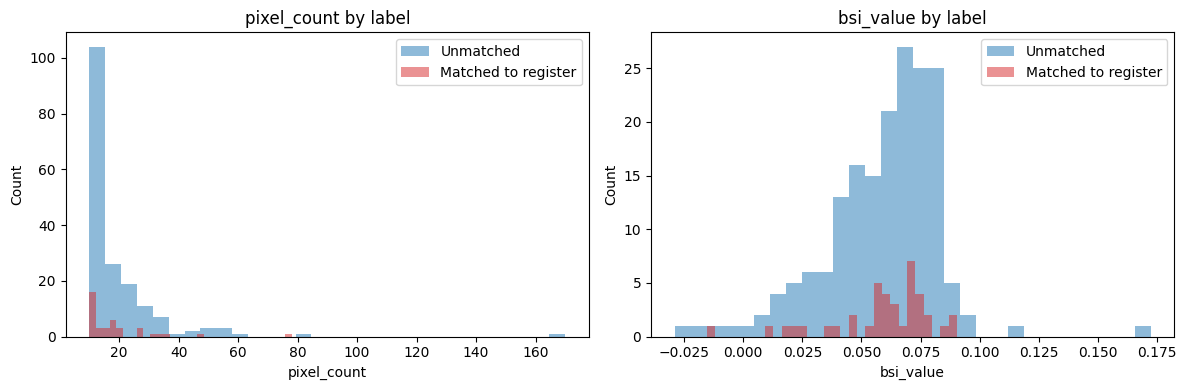

Summary statistics by label:
label                       0          1
pixel_count count  179.000000  39.000000
            mean    19.067039  18.743590
            std     16.044740  13.156383
            min     10.000000  10.000000
            25%     11.000000  10.000000
            50%     14.000000  15.000000
            75%     21.000000  21.000000
            max    170.000000  78.000000
bsi_value   count  179.000000  39.000000
            mean     0.059398   0.058735
            std      0.024493   0.022396
            min     -0.028968  -0.015468
            25%      0.046996   0.055124
            50%      0.064107   0.062809
            75%      0.075332   0.071920
            max      0.172322   0.090504


In [10]:
features_available = ['pixel_count', 'bsi_value']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feature in zip(axes, features_available):
    ax.hist(latest[latest['label'] == 0][feature], bins=30, alpha=0.5,
            label='Unmatched', color='C0')
    ax.hist(latest[latest['label'] == 1][feature], bins=30, alpha=0.5,
            label='Matched to register', color='C3')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.set_title(f'{feature} by label')
    ax.legend()

plt.tight_layout()
plt.show()

print('Summary statistics by label:')
print(latest.groupby('label')[features_available].describe().T)

## 5. Data strategy

There are three ways to scale up the training data before Notebook 08. Stoke only with the current image would leave the dataset at 218 candidates and 39 positives. With 17 features, that is roughly two positive examples per feature and would overfit severely. Multiple councils with one image each would provide a much richer dataset, perhaps 4,000 candidates and 700 positives across 20 councils, but it introduces geographic variation as an additional source of noise while I am still learning the basic mechanics of the classifier.

My chosen strategy is Stoke multi-seasonal. Same council removes geographic noise from the picture. Adding three seasonal Sentinel-2 images should multiply the sample count by roughly a factor of four, giving approximately 600 candidate sites in total and around 120 positive samples. That works out at seven positive examples per feature — marginal for a Random Forest, but sufficient for a first baseline. Just as importantly, the seasonal dimension gives the classifier access to features it cannot otherwise see: the change in a site's spectral signature between spring, summer, and autumn is highly informative for distinguishing brownfield from vegetation-covered scrubland, because scrub changes dramatically across the year and hardstanding does not.

The specific target dates:

| Season | Rough date window | Purpose |
|---|---|---|
| Spring | Late April – early May | Leaf-out beginning, vegetation contrast |
| Summer | Late July – early August | Peak vegetation, brownfield stands out most clearly |
| Autumn | Late September – mid October | Leaves changing, moisture reduced |
| Winter | Skipped | UK cloud cover kills most winter dates |

A note on candidate identity across seasons. The same physical brownfield plot may appear as a candidate in all three seasons, or in only one or two. The vegetation index will mask it out in the seasons when its surface signature aligns with the seasonal baseline. This is a feature of the data rather than a defect. It provides multiple observations of the same underlying object, which is exactly what enables seasonal-delta features. It also means the training rows are not statistically independent — the same site can appear three times with three different feature vectors — and this constrains how the data must be split for validation. Section 7 addresses this directly.

## 6. Class imbalance

At approximately 18% positive, the class balance is not ideal but nor is it catastrophic. It sits in the region where imbalance-handling techniques offer some benefit but are not strictly necessary. The standard responses, in order of complexity, are threshold adjustment, class weighting, and synthetic sampling with SMOTE.

My plan for Notebook 08 is to train both a weighted baseline, using `class_weight='balanced'` from scikit-learn, and an unweighted baseline as a control. If the gap in performance between the two is small, the imbalance is not a real problem and I will drop the extra complexity. If it is significant, I can move up to threshold adjustment or SMOTE as needed. The general principle is not to add complexity until the evidence demands it.

## 7. Validation strategy

A naive 80/20 train/test split of all candidates has two problems.

The first is spatial leakage. Candidates near each other in the same city tend to share soil, drainage, and land-use history. Their spectral signatures correlate. A random split places some near-neighbours in the training set and others in the test set, and the model appears to generalise when in reality it is memorising the local mean.

The second is temporal leakage. The same site observed in spring and summer will be highly correlated. A random split can place those two observations in different sets, and the model can then predict the test example almost trivially from the training one.

My chosen approach is Leave-One-Season-Out cross-validation. This produces three folds: train on spring and summer, test on autumn; train on spring and autumn, test on summer; train on summer and autumn, test on spring. Metrics are averaged across folds. Each site appears in the test set for exactly one fold. Temporal leakage is eliminated by construction. Spatial leakage remains — same-council data across seasons is still spatially correlated — but this is unavoidable when training on a single council.

Once multi-council data becomes available in Phase 4, this strategy generalises naturally to Leave-One-Council-Out cross-validation. Train on 19 councils, test on the 20th. That is closer to how the classifier will actually be deployed — to a new council whose brownfield the model has never seen — and gives a more honest measurement of generalisation.

## 8. Success metrics

The primary metric is recall against the register: the proportion of registered brownfield sites the classifier correctly identifies. The Version 2 baseline sits at 17.9%; the Version 3 target is above 70%.

This is, as noted in Section 3, a proxy metric. It measures whether the classifier has learned the pattern of *known* brownfield, not whether it can find *unknown* brownfield. But if the classifier cannot recover the sites already in the register, it will certainly not find the sites that are not. Recall against the register is a lower bound on real product performance.

The secondary metric is precision — the proportion of positive predictions that actually match the register. A model with 100% recall that flags every candidate as positive is useless: the user would face thousands of leads to review. Precision constrains the leads list to a length a planning officer can realistically work through.

The tertiary metric is PR-AUC, the area under the precision-recall curve. It is more informative than ROC-AUC on imbalanced data because it focuses on the positive class, and it is a useful summary statistic for comparing model configurations against each other.

The classifier is worth deploying if it meets both of the following: recall against register of at least 60% — below the 70% roadmap target, but usably better than the 17.9% baseline; and fewer than 500 unmatched positive predictions per council per image, which is an upper bound on what a planning officer could realistically review. Below either threshold, the classifier does not go into `main.py`. Above both, it does.

## 9. Deferrals

Several natural extensions are deferred to later work. Hyperparameter tuning waits until the baseline reveals whether it is needed. Model comparison against XGBoost and logistic regression follows once the Random Forest baseline is established. Integration into `main.py` and per-council model storage in the `council_models` table both come after the classifier itself has been proven on Stoke. All are on the roadmap; none belong in the first iteration.

## 10. Next steps

Two prerequisites must be complete before Notebook 08.

**Prerequisite A — Expand per-site feature storage.** Extend `calculate_site_properties` in `src/clustering.py` to compute and return the per-band means, the NDVI aggregates, and the hectares figure that is currently discarded. Add a migration file, `002_add_classifier_features.sql`, that introduces the corresponding columns on `candidate_sites`. Update `store_candidate_sites` in `src/database_query.py` to write the new columns. Roughly one session's work.

**Prerequisite B — Acquire Stoke seasonal SAFEs.** Download three additional Sentinel-2 acquisitions for tile T30UWD covering Stoke: one in spring, one in summer, one in autumn 2026. Run the extended pipeline against each. Verify that the classifier feature vectors are correctly stored in `candidate_sites` for each run. The cost is largely wait time — approximately 30 to 45 minutes of downloading, plus around 15 minutes of pipeline execution.

**Then Notebook 08.** Load all candidate sites for Stoke across all seasons. Build the feature matrix and label vector. Train a baseline `RandomForestClassifier` with `class_weight='balanced'`. Evaluate using Leave-One-Season-Out cross-validation. Report recall, precision, and PR-AUC per fold and averaged. Compare against an unweighted baseline as a control experiment. Decide whether the model clears the deployment thresholds set out in Section 8.